# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,
                             f1_score,
                             recall_score,
                             precision_score,
                             confusion_matrix,
                             classification_report)

print("Everthing is Imported Boss")

Everthing is Imported Boss


# **Data Exploration**

## *Load the Data*

In [2]:
file_path = input("Enter the File path: ").replace('\\','\\')
df = pd.read_csv(file_path)
print("Data loaded Boss")

Data loaded Boss


# *Exploration*

In [3]:
print(f"The Dataset have {df.shape[0]} rows and {df.shape[1]} columns with {df.duplicated().sum()} duplicates")

The Dataset have 32300 rows and 10 columns with 298 duplicates


In [4]:
df.head()

,age,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score,is_fraud
0,41.0,2453.81,12686.50,21.0,0.0,9.0,0.0,2438.2,5.2,0
1,49.0,1574.12,36337.02,37.0,0.0,4.0,0.0,2967.1,8.4,1
2,38.0,14897.42,23295.64,21.0,0.0,0.0,0.0,4703.6,3.7,0
3,38.0,9927.23,38586.08,46.0,0.0,17.0,0.0,4281.2,5.5,1
4,61.0,12914.13,2013.73,34.0,0.0,NaN,0.0,4366.7,9.7,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32300 entries, 0 to 32299
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     31656 non-null  str    
 1   transaction_amount      31653 non-null  float64
 2   account_balance         31655 non-null  float64
 3   num_transactions_today  31654 non-null  float64
 4   is_foreign_transaction  31649 non-null  float64
 5   transaction_hour        31657 non-null  float64
 6   prev_fraud_flag         31654 non-null  float64
 7   merchant_distance_km    31657 non-null  float64
 8   merchant_risk_score     31656 non-null  float64
 9   is_fraud                32300 non-null  int64  
dtypes: float64(8), int64(1), str(1)
memory usage: 2.6 MB


In [6]:
df.describe()

,transaction_amount,account_balance,num_transactions_today,is_foreign_transaction,transaction_hour,prev_fraud_flag,merchant_distance_km,merchant_risk_score,is_fraud
count,31653.000000,31655.000000,31654.000000,31649.000000,31657.000000,31654.000000,31657.000000,31656.000000,32300.000000
mean,7471.580234,25020.772509,24.924591,0.145818,11.466532,0.081032,2500.266033,5.512513,0.481734
std,4324.127410,14423.748726,14.150679,0.352929,6.920080,0.272889,1444.739723,2.594919,0.499674
min,1.070000,-99999.000000,1.000000,0.000000,0.000000,0.000000,0.100000,1.000000,0.000000
25%,3723.400000,12510.295000,13.000000,0.000000,5.000000,0.000000,1250.000000,3.300000,0.000000
50%,7475.070000,25050.490000,25.000000,0.000000,11.000000,0.000000,2507.000000,5.500000,0.000000
75%,11199.090000,37530.215000,37.000000,0.000000,17.000000,0.000000,3741.300000,7.800000,1.000000
max,14999.710000,49998.900000,49.000000,1.000000,28.000000,1.000000,4999.800000,15.000000,1.000000


In [7]:
print('NaN values in the dataset Have: ')
print(df.isna().sum())

NaN values in the dataset Have: 
age                       644
transaction_amount        647
account_balance           645
num_transactions_today    646
is_foreign_transaction    651
transaction_hour          643
prev_fraud_flag           646
merchant_distance_km      643
merchant_risk_score       644
is_fraud                    0
dtype: int64


# **Date Cleaning**

## **Create Copy**

In [8]:
df_copy = df.copy()
print('Copy created boss')

Copy created boss


## *DataType*

In [9]:
df_copy['age'] = df_copy['age'].replace('_err','',regex=True).astype('float')

## *Impossible values*

In [10]:
df_copy.loc[df_copy['age']<18,'age'] = np.nan
df_copy.loc[df_copy['age']>80,'age'] = np.nan

df_copy.loc[df_copy['transaction_amount']<0,'transaction_amount'] = np.nan

df_copy.loc[df_copy['account_balance']<0,'account_balance'] = np.nan

df_copy.loc[df_copy['merchant_risk_score']<0,'merchant_risk_score'] = np.nan
df_copy.loc[df_copy['merchant_risk_score']>10,'merchant_risk_score'] = np.nan

## *outliers*

In [11]:
outliers = ['merchant_distance_km',
            'transaction_hour',
            'num_transactions_today',
            'account_balance',
            'transaction_amount']

for outlier in outliers:
    Q1 = df_copy[outlier].quantile(0.25)
    Q3 = df_copy[outlier].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_copy.loc[df_copy[outlier] < lower, outlier] = np.nan
    df_copy.loc[df_copy[outlier] > upper, outlier] = np.nan

print("Outliers Handled ✅")

Outliers Handled ✅


## *Duplicates*

In [12]:
print("Duplicates in the Dataset: ")
print(f"Before: {df_copy.duplicated().sum()}")
df_copy.drop_duplicates(inplace=True)
print(f"After: {df_copy.duplicated().sum()}")


Duplicates in the Dataset: 
Before: 300
After: 0


## *Nan Values*

### Fill Them

In [13]:
print('NaN Values in the dataset: ')
print(df_copy.isna().sum())
# We have NaN in almost all the columns so I use Column funtion here
Columns = df_copy.columns.tolist()
Columns.remove('is_fraud')
for col in Columns:
    df_copy[col] = df_copy[col].fillna(round(df_copy[col].median(),2))
    
print('NaN Values in the dataset After fill: ')
print(df_copy.isna().sum())

NaN Values in the dataset: 
age                       641
transaction_amount        640
account_balance           641
num_transactions_today    640
is_foreign_transaction    640
transaction_hour          640
prev_fraud_flag           640
merchant_distance_km      640
merchant_risk_score       641
is_fraud                    0
dtype: int64
NaN Values in the dataset After fill: 
age                       0
transaction_amount        0
account_balance           0
num_transactions_today    0
is_foreign_transaction    0
transaction_hour          0
prev_fraud_flag           0
merchant_distance_km      0
merchant_risk_score       0
is_fraud                  0
dtype: int64


### Remove Them

In [14]:
df_copy.dropna(inplace=True)
print('NaN dropped')

NaN dropped


## *Confirm*

In [15]:
print(f"The final shape of the dataset after cleaning is {df_copy.shape}")

The final shape of the dataset after cleaning is (32000, 10)


# **Data preperation**

In [16]:
X = df_copy[['age',
 'transaction_amount',
 'account_balance',
 'num_transactions_today',
 'is_foreign_transaction',
 'transaction_hour',
 'prev_fraud_flag',
 'merchant_distance_km',
 'merchant_risk_score']]

y = df_copy['is_fraud']

print(f"X Shape: {X.shape}")
print(f"y Shape: {y.shape}")

X Shape: (32000, 9)
y Shape: (32000,)


In [17]:
X_train,X_test,y_train,y_test = train_test_split(X,
                                                 y,
                                                 train_size=0.8,
                                                 random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f'y_train Shape: {y_train.shape}')
print(f'X_test Shape: {X_test.shape}')
print(f'y_test Shape: {y_test.shape}')

X_train shape: (25600, 9)
y_train Shape: (25600,)
X_test Shape: (6400, 9)
y_test Shape: (6400,)


# **Model**

## **Train**

In [18]:
model = RandomForestClassifier(
    n_estimators=40,
    max_depth=5,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
print("Model trained ✅")

Model trained ✅


## **OBB Score**

In [19]:
# Free accuracy estimate — no test set needed
print(f"OOB Score: {model.oob_score_:.4f}")

OOB Score: 0.7239


## **Test**

In [20]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

              precision    recall  f1-score   support

           0       0.73      0.81      0.77      3389
           1       0.75      0.67      0.71      3011

    accuracy                           0.74      6400
   macro avg       0.74      0.74      0.74      6400
weighted avg       0.74      0.74      0.74      6400

Accuracy: 0.7405


## **Features Importance** 

                  Feature  Importance
6         prev_fraud_flag      0.2638
7    merchant_distance_km      0.2210
4  is_foreign_transaction      0.2109
8     merchant_risk_score      0.1429
1      transaction_amount      0.1167
3  num_transactions_today      0.0234
0                     age      0.0141
5        transaction_hour      0.0054
2         account_balance      0.0018


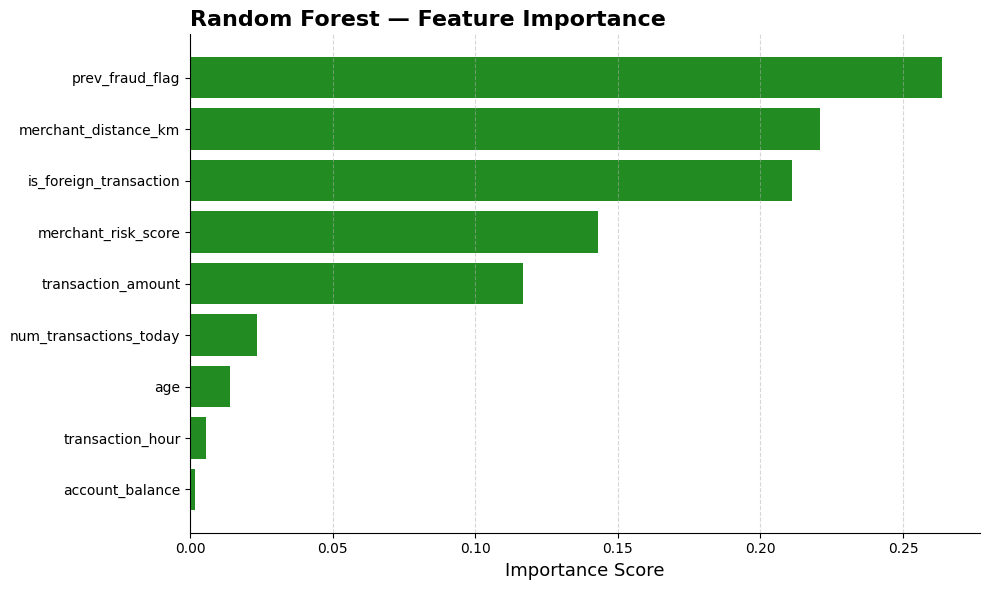

In [21]:
importance_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': model.feature_importances_.round(4)
}).sort_values('Importance', ascending=False)

print(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'],
         importance_df['Importance'],
         color='forestgreen')
ax = plt.gca()
ax.invert_yaxis()
ax.spines[['right','top']].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.5)
plt.xlabel('Importance Score', fontsize=13)
plt.title('Random Forest — Feature Importance',
          fontweight='bold', fontsize=16, loc='left')
plt.tight_layout()
plt.show()

## **Gap**

In [22]:
train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc  = accuracy_score(y_test, y_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Gap:               {(train_acc - test_acc):.4f}")
print(f"OOB Score:         {model.oob_score_:.4f}")

Training Accuracy: 0.7330
Testing Accuracy:  0.7405
Gap:               -0.0075
OOB Score:         0.7239


## **How many trees is enough?**

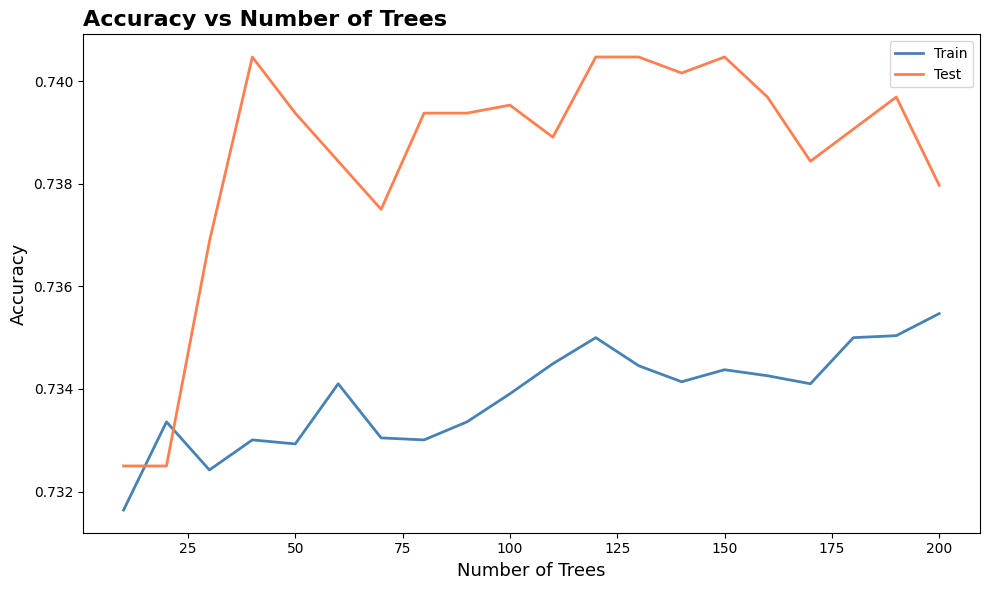

In [ ]:
train_scores = []
test_scores  = []
tree_range   = range(10, 201, 10)

for n in tree_range:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1,max_depth=5)
    rf.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, rf.predict(X_train)))
    test_scores.append(accuracy_score(y_test, rf.predict(X_test)))

plt.figure(figsize=(10, 6))
plt.plot(tree_range, train_scores, label='Train', color='steelblue', linewidth=2)
plt.plot(tree_range, test_scores,  label='Test',  color='coral',     linewidth=2)
plt.xlabel('Number of Trees', fontsize=13)
plt.ylabel('Accuracy', fontsize=13)
plt.title('Accuracy vs Number of Trees',
          fontweight='bold', fontsize=16, loc='left')
plt.legend()
plt.tight_layout()
plt.show()

# **Chart**

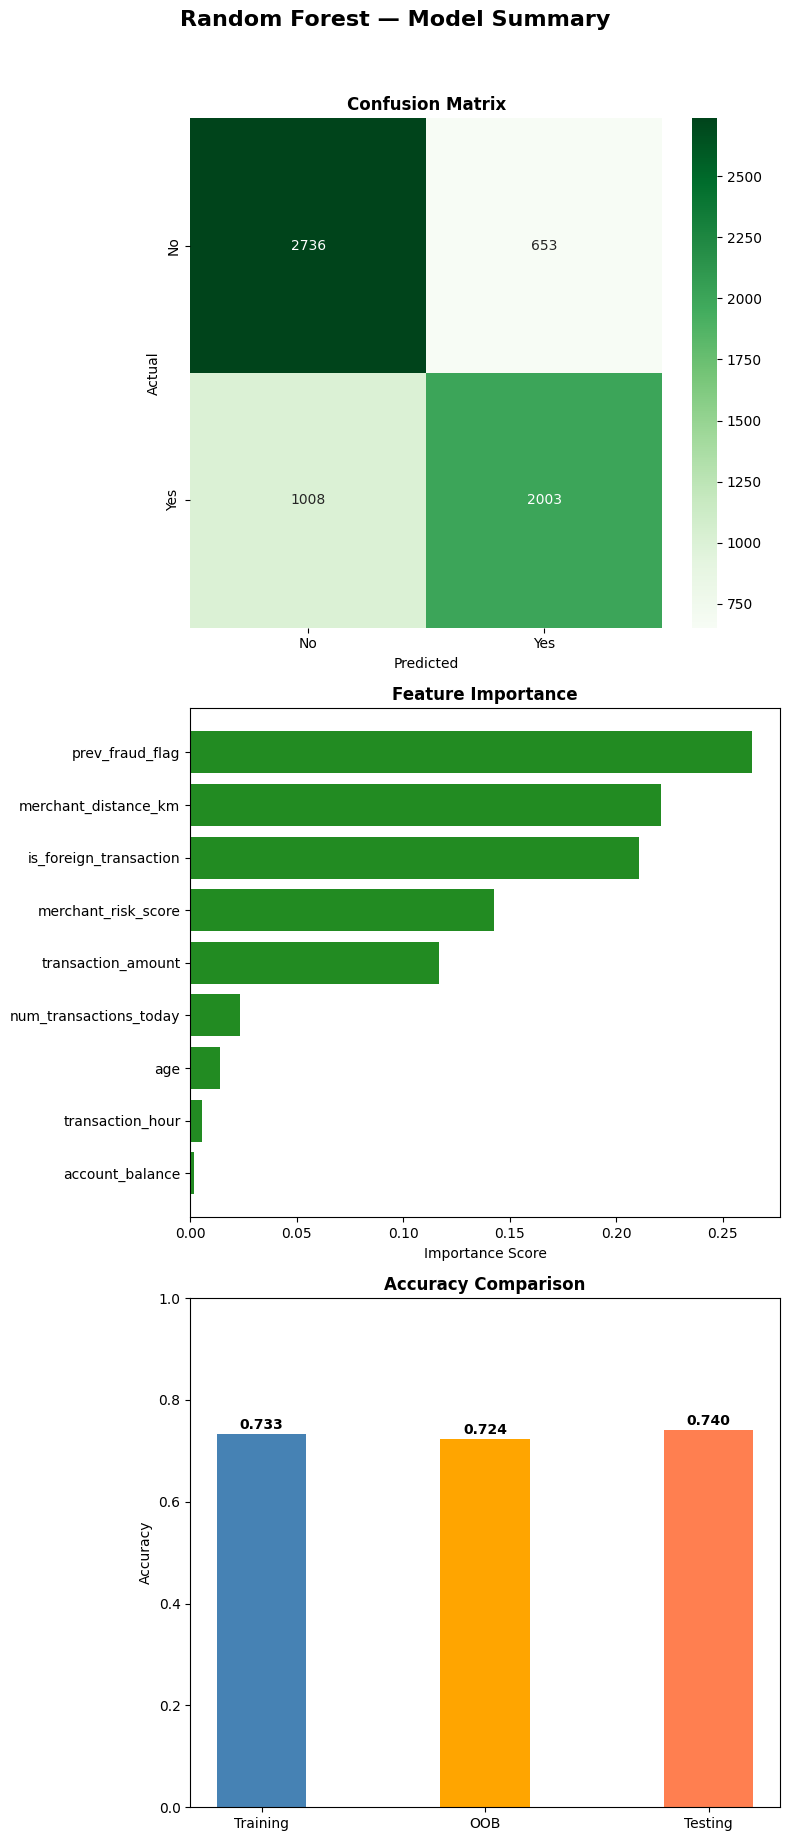

In [24]:
fig, axes = plt.subplots(3, 1, figsize=(8, 18))

# Plot 1 — Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Plot 2 — Feature Importance
imp = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance')
axes[1].barh(imp['Feature'], imp['Importance'], color='forestgreen')
axes[1].set_title('Feature Importance', fontweight='bold')
axes[1].set_xlabel('Importance Score')

# Plot 3 — Train vs Test vs OOB
labels = ['Training', 'OOB', 'Testing']
scores = [train_acc, model.oob_score_, test_acc]
colors = ['steelblue', 'orange', 'coral']
axes[2].bar(labels, scores, color=colors, width=0.4)
axes[2].set_ylim(0, 1)
axes[2].set_title('Accuracy Comparison', fontweight='bold')
axes[2].set_ylabel('Accuracy')
for i, v in enumerate(scores):
    axes[2].text(i, v + 0.01, f'{v:.3f}',
                 ha='center', fontweight='bold')

plt.suptitle('Random Forest — Model Summary',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()